# 📊 Post-traitement MCNP - Notebook optimisé

Ce notebook permet de charger, consolider et analyser tous les résultats MCNP d'une campagne de simulations.

---

In [1]:
from f4enix.output.MCNPoutput import Output
from f4enix.output.mctal import Mctal

# Post-traitement des résultats MCNP

Ce notebook charge et analyse les résultats MCNP de toutes les simulations dans le répertoire `U/`.

## Workflow

1. **Import et configuration** - Modules et chemins
2. **Recherche des métadonnées** - Localisation des fichiers `generated_files.csv`
3. **Extraction des tallies** - Lecture des fichiers MCTAL avec F4Enix
4. **Nettoyage** - Suppression des colonnes techniques inutiles
5. **Sauvegarde** - Export en pickle (complet) et CSV (optimisé)
6. **Exemples d'analyses** - Filtrage et visualisation

## Données extraites par simulation

- **Métadonnées** : configuration, particule, matériau, distance, épaisseur
- **Tallies 14, 24, 34** : valeur et erreur uniquement
- **Tally 1014** : bins d'énergie + valeurs et erreurs pour chaque bin (spectres complets)

## 🧹 Colonnes supprimées du DataFrame final

Pour alléger le DataFrame, les colonnes techniques suivantes sont automatiquement supprimées :
- `path`, `csv_dir`, `full_path` : chemins de fichiers redondants
- `mctal_loaded`, `mctal_path`, `n_tallies`, `tally_numbers` : métadonnées de chargement
- `tally_1014_n_energy_bins` : information redondante (déductible des listes)

## 💾 Formats de sauvegarde

- **Pickle (`.pkl`)** : Données complètes incluant les spectres du tally 1014
- **CSV (`.csv`)** : Données simplifiées (tallies 14/24/34 uniquement, sans les spectres)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

## Configuration des chemins

In [3]:
# Définir le répertoire racine
base_dir = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U')

# Vérifier que le répertoire existe
if not base_dir.exists():
    raise FileNotFoundError(f"Le répertoire {base_dir} n'existe pas")
    
print(f"Répertoire de base: {base_dir}")
print(f"Existe: {base_dir.exists()}")

Répertoire de base: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U
Existe: True


## Fonction pour explorer et charger les résultats

In [4]:
def find_all_csv_files(base_dir):
    """
    Trouve tous les fichiers generated_files.csv dans l'arborescence
    """
    csv_files = []
    for csv_path in Path(base_dir).rglob('generated_files.csv'):
        csv_files.append(csv_path)
    return csv_files

def load_metadata_from_csv(csv_path):
    """
    Charge les métadonnées depuis un fichier CSV
    Retourne un DataFrame avec le chemin complet vers les fichiers .m
    """
    df = pd.read_csv(csv_path)
    
    # Ajouter le répertoire parent du CSV
    csv_dir = csv_path.parent
    
    # Construire le chemin complet vers les fichiers .m
    df['csv_dir'] = str(csv_dir)
    df['full_path'] = df.apply(
        lambda row: csv_dir / row['path'] / row['file'].replace('.i', '.m'), 
        axis=1
    )
    
    # Extraire des informations de hiérarchie depuis le chemin
    # Format: .../U/C1/N/concrete/...
    parts = csv_dir.parts
    u_index = parts.index('U') if 'U' in parts else None
    
    if u_index is not None and len(parts) > u_index + 3:
        df['config'] = parts[u_index + 1]  # C1, C4, etc.
        df['particle'] = parts[u_index + 2]  # N, P
        df['material'] = parts[u_index + 3]  # concrete, lead, steel, water
    else:
        df['config'] = None
        df['particle'] = None
        df['material'] = None
    
    return df

# Tester la fonction
csv_files = find_all_csv_files(base_dir)
print(f"Nombre de fichiers CSV trouvés: {len(csv_files)}")
print(f"\nPremiers fichiers CSV:")
for csv in csv_files[:5]:
    print(f"  {csv}")

Nombre de fichiers CSV trouvés: 16

Premiers fichiers CSV:
  /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/concrete/generated_files.csv
  /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/steel/generated_files.csv
  /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/lead/generated_files.csv
  /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/water/generated_files.csv
  /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/P/concrete/generated_files.csv


## Chargement des métadonnées de tous les CSV

In [5]:
# Charger toutes les métadonnées
all_metadata = []

for csv_path in csv_files:
    try:
        df_meta = load_metadata_from_csv(csv_path)
        all_metadata.append(df_meta)
        print(f"✓ Chargé: {csv_path.relative_to(base_dir)} ({len(df_meta)} entrées)")
    except Exception as e:
        print(f"✗ Erreur avec {csv_path}: {e}")

# Concaténer toutes les métadonnées
df_metadata = pd.concat(all_metadata, ignore_index=True)

print(f"\n{'='*60}")
print(f"Total des simulations trouvées: {len(df_metadata)}")
print(f"{'='*60}")
print(f"\nRépartition par configuration:")
print(df_metadata.groupby(['config', 'particle', 'material']).size())

✓ Chargé: C1/N/concrete/generated_files.csv (26 entrées)
✓ Chargé: C1/N/steel/generated_files.csv (52 entrées)
✓ Chargé: C1/N/lead/generated_files.csv (52 entrées)
✓ Chargé: C1/N/water/generated_files.csv (52 entrées)
✓ Chargé: C1/P/concrete/generated_files.csv (26 entrées)
✓ Chargé: C1/P/lead/generated_files.csv (1 entrées)
✓ Chargé: C1/P/steel/generated_files.csv (52 entrées)
✓ Chargé: C1/P/water/generated_files.csv (52 entrées)
✓ Chargé: C4/P/water/generated_files.csv (52 entrées)
✓ Chargé: C4/P/steel/generated_files.csv (26 entrées)
✓ Chargé: C4/P/lead/generated_files.csv (9 entrées)
✓ Chargé: C4/P/concrete/generated_files.csv (9 entrées)
✓ Chargé: C4/N/water/generated_files.csv (52 entrées)
✓ Chargé: C4/N/steel/generated_files.csv (52 entrées)
✓ Chargé: C4/N/lead/generated_files.csv (52 entrées)
✓ Chargé: C4/N/concrete/generated_files.csv (26 entrées)

Total des simulations trouvées: 591

Répartition par configuration:
config  particle  material
C1      N         concrete    26
  

## Chargement des fichiers MCTAL avec F4Enix

## Fonction d'extraction des tallies avec F4Enix

In [6]:
def load_mctal_with_tallies(mctal_path):
    """
    Charge un fichier MCTAL avec F4Enix et extrait toutes les données des tallies
    
    Retourne un dictionnaire avec :
    - Les informations générales
    - Pour tallies 14, 24, 34 : uniquement value et error
    - Pour tally 1014 : bins d'énergie, valeurs et erreurs pour chaque bin
    """
    try:
        # Charger le fichier MCTAL
        mctal = Mctal(str(mctal_path))
        
        # Dictionnaire pour stocker les résultats
        results = {
            'mctal_loaded': True,
            'mctal_path': str(mctal_path),
            'n_tallies': len(mctal.tallies),
            'tally_numbers': list(mctal.tallydata.keys()),
        }
        
        # Pour chaque tally, extraire les informations
        for tally_num in mctal.tallydata.keys():
            prefix = f'tally_{tally_num}_'
            
            # Données du tally
            tally_df = mctal.tallydata[tally_num]
            
            # Traitement spécifique selon le tally
            if tally_num in [14, 24, 34]:
                # Pour les tallies 14, 24, 34 : seulement value et error
                if len(tally_df) == 1:
                    results[f'{prefix}value'] = tally_df['Value'].iloc[0]
                    results[f'{prefix}error'] = tally_df['Error'].iloc[0]
                else:
                    # Si plusieurs bins (cas inattendu), prendre la somme ou moyenne
                    results[f'{prefix}value'] = tally_df['Value'].sum()
                    results[f'{prefix}error'] = tally_df['Error'].mean()
                    
            elif tally_num == 1014:
                # Pour le tally 1014 : récupérer les bins d'énergie et les valeurs/erreurs
                # Récupérer les informations du tally complet (pas juste tallydata)
                tally_obj = mctal.tallies[[t.tallyNumber for t in mctal.tallies].index(1014)]
                
                # Les bins d'énergie sont dans tally_obj.erg
                if hasattr(tally_obj, 'erg') and tally_obj.erg is not None:
                    results[f'{prefix}energy_bins'] = tally_obj.erg.tolist() if hasattr(tally_obj.erg, 'tolist') else list(tally_obj.erg)
                
                # Les valeurs et erreurs pour chaque bin
                results[f'{prefix}values'] = tally_df['Value'].tolist()
                results[f'{prefix}errors'] = tally_df['Error'].tolist()
                results[f'{prefix}n_energy_bins'] = len(tally_df)
                
            else:
                # Pour les autres tallies (si présents)
                if len(tally_df) == 1:
                    results[f'{prefix}value'] = tally_df['Value'].iloc[0]
                    results[f'{prefix}error'] = tally_df['Error'].iloc[0]
                else:
                    results[f'{prefix}values'] = tally_df['Value'].tolist()
                    results[f'{prefix}errors'] = tally_df['Error'].tolist()
        
        return results
        
    except FileNotFoundError:
        return {
            'mctal_loaded': False,
            'mctal_path': str(mctal_path),
            'error': 'File not found'
        }
    except Exception as e:
        return {
            'mctal_loaded': False,
            'mctal_path': str(mctal_path),
            'error': str(e)
        }

# Test de la fonction sur un fichier exemple
test_mctal = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/concrete/wall_thk_cm=20.0/D_m=1.0/SR-U-UN-G1-C1-N_concrete_20cm_D1m.m')

if test_mctal.exists():
    print("Test de la fonction sur un fichier exemple:")
    print("="*60)
    print(f"Fichier: {test_mctal.name}")
    test_results = load_mctal_with_tallies(test_mctal)
    
    print(f"\nRésultats du chargement:")
    for key, value in test_results.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.6e}")
        elif isinstance(value, list) and len(value) > 5:
            print(f"  {key}: [liste de {len(value)} éléments]")
        else:
            print(f"  {key}: {value}")
else:
    print(f"⚠️  Fichier de test non trouvé: {test_mctal}")
    print("La fonction sera testée lors du chargement complet.")

Test de la fonction sur un fichier exemple:
Fichier: SR-U-UN-G1-C1-N_concrete_20cm_D1m.m

Résultats du chargement:
  mctal_loaded: True
  mctal_path: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/concrete/wall_thk_cm=20.0/D_m=1.0/SR-U-UN-G1-C1-N_concrete_20cm_D1m.m
  n_tallies: 4
  tally_numbers: [14, 24, 34, 1014]
  tally_14_value: 9.230600e-06
  tally_14_error: 1.480000e-02
  tally_24_value: 9.766370e-05
  tally_24_error: 1.710000e-02
  tally_34_value: 8.374190e-05
  tally_34_error: 1.420000e-02
  tally_1014_energy_bins: [liste de 232 éléments]
  tally_1014_values: [liste de 233 éléments]
  tally_1014_errors: [liste de 233 éléments]
  tally_1014_n_energy_bins: 233

Résultats du chargement:
  mctal_loaded: True
  mctal_path: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/U/C1/N/concrete/wall_thk_cm=20.0/D_m=1.0/SR-U-UN-G1-C1-N_concrete_20cm_D1m.m
  n_tallies: 4
  tally_numbers: [14, 24, 34, 1014]
  tally_14_value: 9.230600e-06
  tally_14_error: 1.480000e-02
  tally_24_value: 9

In [7]:
# Test de la fonction mise à jour
print("Test de la fonction mise à jour:")
print("="*60)
test_results_v2 = load_mctal_with_tallies(test_mctal)

print("\nInformations générales:")
for key in ['mctal_loaded', 'n_tallies', 'tally_numbers']:
    if key in test_results_v2:
        print(f"  {key}: {test_results_v2[key]}")

print("\nTallies 14, 24, 34 (seulement value et error):")
for tally_num in [14, 24, 34]:
    print(f"\n  Tally {tally_num}:")
    prefix = f'tally_{tally_num}_'
    for key in ['value', 'error']:
        full_key = f'{prefix}{key}'
        if full_key in test_results_v2:
            print(f"    {key}: {test_results_v2[full_key]:.6e}")

print("\nTally 1014 (bins d'énergie et valeurs):")
if 'tally_1014_n_energy_bins' in test_results_v2:
    n_bins = test_results_v2['tally_1014_n_energy_bins']
    print(f"  Nombre de bins d'énergie: {n_bins}")
    
    if 'tally_1014_energy_bins' in test_results_v2:
        energy_bins = test_results_v2['tally_1014_energy_bins']
        print(f"  Premiers bins d'énergie: {energy_bins[:5]}")
        print(f"  Derniers bins d'énergie: {energy_bins[-5:]}")
    
    if 'tally_1014_values' in test_results_v2:
        values = test_results_v2['tally_1014_values']
        print(f"  Premières valeurs: {values[:5]}")
        print(f"  Type des valeurs: {type(values)}, longueur: {len(values)}")
    
    if 'tally_1014_errors' in test_results_v2:
        errors = test_results_v2['tally_1014_errors']
        print(f"  Premières erreurs: {errors[:5]}")

print("\n" + "="*60)
print(f"Nombre total de clés dans le dictionnaire: {len(test_results_v2)}")
print(f"Clés disponibles: {list(test_results_v2.keys())}")

Test de la fonction mise à jour:

Informations générales:
  mctal_loaded: True
  n_tallies: 4
  tally_numbers: [14, 24, 34, 1014]

Tallies 14, 24, 34 (seulement value et error):

  Tally 14:
    value: 9.230600e-06
    error: 1.480000e-02

  Tally 24:
    value: 9.766370e-05
    error: 1.710000e-02

  Tally 34:
    value: 8.374190e-05
    error: 1.420000e-02

Tally 1014 (bins d'énergie et valeurs):
  Nombre de bins d'énergie: 233
  Premiers bins d'énergie: [1e-11, 1e-09, 2.15e-09, 4.64e-09, 1e-08]
  Derniers bins d'énergie: [15.0, 16.0, 17.0, 18.0, 20.0]
  Premières valeurs: [0.0, 6.30103e-11, 2.39286e-10, 1.70335e-09, 5.71219e-09]
  Type des valeurs: <class 'list'>, longueur: 233
  Premières erreurs: [0.0, 0.2371, 0.1489, 0.2394, 0.1091]

Nombre total de clés dans le dictionnaire: 14
Clés disponibles: ['mctal_loaded', 'mctal_path', 'n_tallies', 'tally_numbers', 'tally_14_value', 'tally_14_error', 'tally_24_value', 'tally_24_error', 'tally_34_value', 'tally_34_error', 'tally_1014_energ

## Chargement de tous les fichiers MCTAL

**Note:** Cette opération peut prendre plusieurs minutes selon le nombre de fichiers.

In [8]:
# Charger tous les fichiers MCTAL avec les tallies
all_results_with_tallies = []
n_total = len(df_metadata)
n_loaded = 0
n_failed = 0

print(f"Chargement de {n_total} fichiers MCTAL avec extraction des tallies...")
print(f"{'='*60}")

for idx, row in df_metadata.iterrows():
    mctal_path = row['full_path']
    
    # Charger le fichier MCTAL avec les tallies
    mctal_results = load_mctal_with_tallies(mctal_path)
    
    # Combiner avec les métadonnées
    combined_results = {**row.to_dict(), **mctal_results}
    all_results_with_tallies.append(combined_results)
    
    # Affichage de progression
    if mctal_results.get('mctal_loaded', False):
        n_loaded += 1
        if (idx + 1) % 50 == 0:
            print(f"  Progression: {idx+1}/{n_total} - Chargés: {n_loaded}, Échoués: {n_failed}")
    else:
        n_failed += 1
        if n_failed <= 5:  # Afficher seulement les 5 premiers échecs
            print(f"  ✗ Échec: {mctal_path.name} - {mctal_results.get('error', 'Unknown error')}")

print(f"{'='*60}")
print(f"\nRésumé:")
print(f"  Total: {n_total}")
print(f"  Chargés avec succès: {n_loaded}")
print(f"  Échecs: {n_failed}")

# Créer le DataFrame initial avec toutes les données
df_temp = pd.DataFrame(all_results_with_tallies)

# Supprimer les colonnes inutiles du DataFrame final
cols_to_remove = [
    'path', 'csv_dir', 'full_path',  # Chemins de fichiers
    'mctal_loaded', 'mctal_path', 'n_tallies', 'tally_numbers',  # Métadonnées de chargement
    'tally_1014_n_energy_bins',  # Info du tally 1014
]
cols_to_remove_existing = [col for col in cols_to_remove if col in df_temp.columns]

# Créer le DataFrame final sans ces colonnes
df_results_final = df_temp.drop(columns=cols_to_remove_existing)

print(f"\nDataFrame final créé avec {len(df_results_final)} lignes et {len(df_results_final.columns)} colonnes")
print(f"Colonnes supprimées ({len(cols_to_remove_existing)}): {cols_to_remove_existing}")
print(f"\nColonnes conservées:")
print(df_results_final.columns.tolist())

Chargement de 591 fichiers MCTAL avec extraction des tallies...
  Progression: 50/591 - Chargés: 50, Échoués: 0
  Progression: 50/591 - Chargés: 50, Échoués: 0
  Progression: 100/591 - Chargés: 100, Échoués: 0
  Progression: 100/591 - Chargés: 100, Échoués: 0
  Progression: 150/591 - Chargés: 150, Échoués: 0
  Progression: 150/591 - Chargés: 150, Échoués: 0
  ✗ Échec: SR-U-UN-G1-C1-P_concrete_40cm_D1m.m - File not found
  Progression: 200/591 - Chargés: 199, Échoués: 1
  ✗ Échec: SR-U-UN-G1-C1-P_concrete_40cm_D1m.m - File not found
  Progression: 200/591 - Chargés: 199, Échoués: 1
  ✗ Échec: SR-U-UN-G1-C1-P_lead_20cm_D1000m.m - File not found
  ✗ Échec: SR-U-UN-G1-C1-P_lead_20cm_D1000m.m - File not found
  Progression: 250/591 - Chargés: 248, Échoués: 2
  Progression: 250/591 - Chargés: 248, Échoués: 2
  Progression: 300/591 - Chargés: 298, Échoués: 2
  Progression: 300/591 - Chargés: 298, Échoués: 2
  Progression: 350/591 - Chargés: 348, Échoués: 2
  Progression: 350/591 - Chargés: 34

In [9]:
# Vérification rapide : afficher les colonnes qui ont été supprimées et celles qui restent
print("📊 RÉSUMÉ DES COLONNES DU DATAFRAME FINAL")
print("="*60)
print(f"\nNombre total de colonnes : {len(df_results_final.columns)}")
print(f"\nColonnes conservées dans df_results_final :")
for i, col in enumerate(df_results_final.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n{'='*60}")
print(f"Colonnes SUPPRIMÉES (non présentes dans df_results_final) :")
suppressed = ['path', 'csv_dir', 'full_path', 'mctal_loaded', 'mctal_path', 
              'n_tallies', 'tally_numbers', 'tally_1014_n_energy_bins']
for col in suppressed:
    status = "❌" if col not in df_results_final.columns else "⚠️  ENCORE PRÉSENTE"
    print(f"  • {col}: {status}")
print("="*60)

📊 RÉSUMÉ DES COLONNES DU DATAFRAME FINAL

Nombre total de colonnes : 17

Colonnes conservées dans df_results_final :
   1. file
   2. D_m
   3. rfis_cm
   4. wall_thk_cm
   5. config
   6. particle
   7. material
   8. tally_14_value
   9. tally_14_error
  10. tally_24_value
  11. tally_24_error
  12. tally_34_value
  13. tally_34_error
  14. tally_1014_energy_bins
  15. tally_1014_values
  16. tally_1014_errors
  17. error

Colonnes SUPPRIMÉES (non présentes dans df_results_final) :
  • path: ❌
  • csv_dir: ❌
  • full_path: ❌
  • mctal_loaded: ❌
  • mctal_path: ❌
  • n_tallies: ❌
  • tally_numbers: ❌
  • tally_1014_n_energy_bins: ❌


## Aperçu des résultats

In [10]:
# Afficher un aperçu des résultats
print("Aperçu des premières lignes:")
print("="*60)

# Sélectionner quelques colonnes clés pour l'affichage
key_cols = ['config', 'particle', 'material', 'D_m', 'wall_thk_cm', 
            'tally_14_value', 'tally_14_error']
# Ne garder que les colonnes qui existent
key_cols = [col for col in key_cols if col in df_results_final.columns]
display(df_results_final[key_cols].head(10))

# Statistiques sur les tallies
print(f"\n{'='*60}")
print("Statistiques des tallies:")
print(f"{'='*60}")

if 'tally_14_value' in df_results_final.columns:
    print(f"\nTally 14:")
    print(f"  Valeurs chargées: {df_results_final['tally_14_value'].notna().sum()}")
    print(f"  Valeur moyenne: {df_results_final['tally_14_value'].mean():.6e}")
    print(f"  Erreur moyenne: {df_results_final['tally_14_error'].mean():.4f}")

if 'tally_24_value' in df_results_final.columns:
    print(f"\nTally 24:")
    print(f"  Valeurs chargées: {df_results_final['tally_24_value'].notna().sum()}")
    print(f"  Valeur moyenne: {df_results_final['tally_24_value'].mean():.6e}")
    print(f"  Erreur moyenne: {df_results_final['tally_24_error'].mean():.4f}")

if 'tally_34_value' in df_results_final.columns:
    print(f"\nTally 34:")
    print(f"  Valeurs chargées: {df_results_final['tally_34_value'].notna().sum()}")
    print(f"  Valeur moyenne: {df_results_final['tally_34_value'].mean():.6e}")
    print(f"  Erreur moyenne: {df_results_final['tally_34_error'].mean():.4f}")

if 'tally_1014_values' in df_results_final.columns:
    print(f"\nTally 1014:")
    print(f"  Simulations avec tally 1014: {df_results_final['tally_1014_values'].notna().sum()}")
    print(f"  Spectres complets stockés dans le pickle (energy_bins, values, errors)")
    print(f"  Note: Ces données volumineuses sont exclues du CSV")

Aperçu des premières lignes:


,config,particle,material,D_m,wall_thk_cm,tally_14_value,tally_14_error
0,C1,N,concrete,1.0,20.0,9.230600e-06,0.0148
1,C1,N,concrete,2.0,20.0,3.353110e-06,0.0435
2,C1,N,concrete,5.0,20.0,5.631540e-07,0.0472
3,C1,N,concrete,10.0,20.0,1.389850e-07,0.0399
4,C1,N,concrete,20.0,20.0,3.349870e-08,0.0309
5,C1,N,concrete,50.0,20.0,4.831780e-09,0.0349
6,C1,N,concrete,100.0,20.0,1.024380e-09,0.0285
7,C1,N,concrete,200.0,20.0,1.727130e-10,0.0236
8,C1,N,concrete,300.0,20.0,5.010790e-11,0.0234
9,C1,N,concrete,500.0,20.0,7.226600e-12,0.0262



Statistiques des tallies:

Tally 14:
  Valeurs chargées: 588
  Valeur moyenne: 3.451808e-06
  Erreur moyenne: 0.0396

Tally 24:
  Valeurs chargées: 588
  Valeur moyenne: 4.037506e-05
  Erreur moyenne: 0.0393

Tally 34:
  Valeurs chargées: 588
  Valeur moyenne: 3.151706e-05
  Erreur moyenne: 0.0405

Tally 1014:
  Simulations avec tally 1014: 588
  Spectres complets stockés dans le pickle (energy_bins, values, errors)
  Note: Ces données volumineuses sont exclues du CSV


## Sauvegarde des résultats

In [11]:
# Sauvegarder les résultats finaux

# 1. Sauvegarder TOUT en pickle (y compris le tally 1014 complet)
output_pkl = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.pkl')
df_results_final.to_pickle(output_pkl)
print(f"✓ Résultats complets sauvegardés en pickle: {output_pkl}")
print(f"  (Inclut toutes les données du tally 1014: energy_bins, values, errors)")

# 2. Sauvegarder en CSV SANS les colonnes spectrales du tally 1014
# Colonnes du tally 1014 à exclure du CSV (listes volumineuses)
tally_1014_spectral_cols = [col for col in df_results_final.columns 
                            if col in ['tally_1014_energy_bins', 'tally_1014_values', 'tally_1014_errors']]

# Créer un DataFrame sans les colonnes spectrales pour le CSV
df_for_csv = df_results_final.drop(columns=tally_1014_spectral_cols) if tally_1014_spectral_cols else df_results_final

output_csv = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv')
df_for_csv.to_csv(output_csv, index=False)
print(f"\n✓ Résultats sauvegardés en CSV: {output_csv}")
if tally_1014_spectral_cols:
    print(f"  (Colonnes spectrales tally 1014 exclues: {tally_1014_spectral_cols})")

# Optionnel: sauvegarder en Excel (décommenter si besoin)
# output_xlsx = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.xlsx')
# df_for_csv.to_excel(output_xlsx, index=False, engine='openpyxl')
# print(f"\n✓ Résultats sauvegardés en Excel: {output_xlsx}")

print(f"\n{'='*60}")
print(f"SAUVEGARDE TERMINÉE")
print(f"{'='*60}")
print(f"Nombre de simulations: {len(df_results_final)}")
print(f"Nombre de colonnes dans le DataFrame (pickle): {len(df_results_final.columns)}")
print(f"Nombre de colonnes dans le CSV: {len(df_for_csv.columns)}")
print(f"\nColonnes du DataFrame/pickle:")
print(df_results_final.columns.tolist())
print(f"\nTaille du fichier CSV: {output_csv.stat().st_size / 1024:.2f} KB")
print(f"Taille du fichier pickle: {output_pkl.stat().st_size / 1024 / 1024:.2f} MB")

✓ Résultats complets sauvegardés en pickle: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.pkl
  (Inclut toutes les données du tally 1014: energy_bins, values, errors)

✓ Résultats sauvegardés en CSV: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv
  (Colonnes spectrales tally 1014 exclues: ['tally_1014_energy_bins', 'tally_1014_values', 'tally_1014_errors'])

SAUVEGARDE TERMINÉE
Nombre de simulations: 591
Nombre de colonnes dans le DataFrame (pickle): 17
Nombre de colonnes dans le CSV: 14

Colonnes du DataFrame/pickle:
['file', 'D_m', 'rfis_cm', 'wall_thk_cm', 'config', 'particle', 'material', 'tally_14_value', 'tally_14_error', 'tally_24_value', 'tally_24_error', 'tally_34_value', 'tally_34_error', 'tally_1014_energy_bins', 'tally_1014_values', 'tally_1014_errors', 'error']

Taille du fichier CSV: 69.61 KB
Taille du fichier pickle: 2.65 MB


## Exemples d'analyses

In [12]:
# Exemple 1: Évolution du tally 14 en fonction de la distance pour béton/C1/N
df_plot = df_results_final[
    (df_results_final['config'] == 'C1') & 
    (df_results_final['particle'] == 'N') & 
    (df_results_final['material'] == 'concrete') &
    (df_results_final['wall_thk_cm'] == 20.0)
].sort_values('D_m')

if len(df_plot) > 0:
    print("Évolution du Tally 14 en fonction de la distance")
    print("Configuration: C1, Neutrons, Béton, 20 cm d'épaisseur")
    print("="*60)
    display(df_plot[['D_m', 'tally_14_value', 'tally_14_error', 'tally_24_value', 'tally_24_error']])
    
    # Vous pouvez créer un graphique avec matplotlib
    # import matplotlib.pyplot as plt
    # plt.figure(figsize=(10, 6))
    # plt.loglog(df_plot['D_m'], df_plot['tally_14_value'], 'o-', label='Tally 14')
    # plt.loglog(df_plot['D_m'], df_plot['tally_24_value'], 's-', label='Tally 24')
    # plt.xlabel('Distance (m)')
    # plt.ylabel('Valeur du tally')
    # plt.legend()
    # plt.grid(True)
    # plt.title('Évolution des tallies en fonction de la distance')
    # plt.show()

Évolution du Tally 14 en fonction de la distance
Configuration: C1, Neutrons, Béton, 20 cm d'épaisseur


,D_m,tally_14_value,tally_14_error,tally_24_value,tally_24_error
0,1.0,9.230600e-06,0.0148,9.766370e-05,0.0171
1,2.0,3.353110e-06,0.0435,3.406510e-05,0.0355
2,5.0,5.631540e-07,0.0472,5.795730e-06,0.0435
3,10.0,1.389850e-07,0.0399,1.455340e-06,0.0394
4,20.0,3.349870e-08,0.0309,3.306830e-07,0.0267
5,50.0,4.831780e-09,0.0349,4.913950e-08,0.0348
6,100.0,1.024380e-09,0.0285,1.052540e-08,0.0287
7,200.0,1.727130e-10,0.0236,1.861500e-09,0.0221
8,300.0,5.010790e-11,0.0234,5.547870e-10,0.0227
9,500.0,7.226600e-12,0.0262,8.129300e-11,0.0255


In [13]:
# Exemple 2: Comparaison des matériaux pour une distance donnée
df_compare = df_results_final[
    (df_results_final['config'] == 'C1') & 
    (df_results_final['particle'] == 'N') & 
    (df_results_final['D_m'] == 100.0) &
    (df_results_final['wall_thk_cm'] == 20.0)
].sort_values('material')

if len(df_compare) > 0:
    print("\nComparaison des matériaux à D = 100 m")
    print("Configuration: C1, Neutrons, 20 cm d'épaisseur")
    print("="*60)
    display(df_compare[['material', 'tally_14_value', 'tally_14_error', 
                        'tally_24_value', 'tally_24_error', 'tally_34_value', 'tally_34_error']])


Comparaison des matériaux à D = 100 m
Configuration: C1, Neutrons, 20 cm d'épaisseur


,material,tally_14_value,tally_14_error,tally_24_value,tally_24_error,tally_34_value,tally_34_error
6,concrete,1.024380e-09,0.0285,1.052540e-08,0.0287,8.604060e-09,0.0341
123,lead,2.964090e-09,0.0138,3.578980e-08,0.0136,2.395970e-08,0.0144
71,steel,1.590450e-09,0.0139,2.009970e-08,0.0139,1.204730e-08,0.0135
175,water,4.972630e-10,0.0591,5.329570e-09,0.0520,4.685900e-09,0.0631


## Recharger les résultats sauvegardés

In [14]:
# Recharger les résultats depuis le fichier pickle (plus rapide que de tout recharger)
# df_results_final = pd.read_pickle('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.pkl')
# print(f"Résultats rechargés: {len(df_results_final)} simulations, {len(df_results_final.columns)} colonnes")

# Ou depuis le CSV (plus lent mais plus portable)
# df_results_final = pd.read_csv('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv')
# print(f"Résultats rechargés: {len(df_results_final)} simulations, {len(df_results_final.columns)} colonnes")

## Accéder aux spectres du Tally 1014

In [15]:
# Exemple d'accès aux données du tally 1014 pour une simulation spécifique

# Sélectionner une simulation
example_row = df_results_final[
    (df_results_final['config'] == 'C1') & 
    (df_results_final['particle'] == 'N') & 
    (df_results_final['material'] == 'concrete') &
    (df_results_final['D_m'] == 1.0) &
    (df_results_final['wall_thk_cm'] == 20.0)
].iloc[0]

if 'tally_1014_energy_bins' in example_row.index and example_row['tally_1014_energy_bins'] is not None:
    print("Exemple de données Tally 1014:")
    print("="*60)
    print(f"Configuration: {example_row['config']}, {example_row['particle']}, {example_row['material']}")
    print(f"Distance: {example_row['D_m']} m, Épaisseur: {example_row['wall_thk_cm']} cm")
    print()
    
    energy_bins = example_row['tally_1014_energy_bins']
    values = example_row['tally_1014_values']
    errors = example_row['tally_1014_errors']
    
    print(f"Nombre de bins d'énergie (bornes): {len(energy_bins)}")
    print(f"Nombre de valeurs: {len(values)}")
    print(f"Nombre d'erreurs: {len(errors)}")
    print()
    
    # Note: F4Enix donne N bins d'énergie (bornes) et N+1 valeurs
    # La dernière valeur correspond au total
    print(f"\nPremiers intervalles d'énergie:")
    for i in range(min(5, len(energy_bins))):
        if i < len(values):
            print(f"  [{energy_bins[i]:.3e} - {energy_bins[min(i+1, len(energy_bins)-1)]:.3e}] MeV: valeur = {values[i]:.3e}, erreur = {errors[i]:.4f}")
    
    # Créer un DataFrame pour faciliter l'analyse
    # On garde seulement les valeurs qui correspondent aux bins d'énergie
    # Les bins d'énergie sont les bornes, la dernière valeur dans values est le total
    n_bins = len(energy_bins) - 1  # Nombre d'intervalles
    
    spectrum_df = pd.DataFrame({
        'Energy_Lower_MeV': energy_bins[:n_bins],
        'Energy_Upper_MeV': energy_bins[1:],
        'Value': values[:n_bins],
        'Error': errors[:n_bins]
    })
    
    print(f"\nSpectre sous forme de DataFrame (premiers bins):")
    display(spectrum_df.head(10))
    
    # Ajouter la valeur totale si elle existe
    if len(values) > len(energy_bins):
        print(f"\nValeur totale (dernière valeur):")
        print(f"  Valeur: {values[-1]:.3e}")
        print(f"  Erreur: {errors[-1]:.4f}")
    
    # Exemple de traitement: trouver le pic d'énergie
    max_idx = spectrum_df['Value'].idxmax()
    print(f"\nPic du spectre:")
    print(f"  Intervalle: [{spectrum_df.loc[max_idx, 'Energy_Lower_MeV']:.3e} - {spectrum_df.loc[max_idx, 'Energy_Upper_MeV']:.3e}] MeV")
    print(f"  Valeur: {spectrum_df.loc[max_idx, 'Value']:.3e}")
    print(f"  Erreur: {spectrum_df.loc[max_idx, 'Error']:.4f}")
else:
    print("Pas de données tally 1014 disponibles pour cet exemple")

Exemple de données Tally 1014:
Configuration: C1, N, concrete
Distance: 1.0 m, Épaisseur: 20.0 cm

Nombre de bins d'énergie (bornes): 232
Nombre de valeurs: 233
Nombre d'erreurs: 233


Premiers intervalles d'énergie:
  [1.000e-11 - 1.000e-09] MeV: valeur = 0.000e+00, erreur = 0.0000
  [1.000e-09 - 2.150e-09] MeV: valeur = 6.301e-11, erreur = 0.2371
  [2.150e-09 - 4.640e-09] MeV: valeur = 2.393e-10, erreur = 0.1489
  [4.640e-09 - 1.000e-08] MeV: valeur = 1.703e-09, erreur = 0.2394
  [1.000e-08 - 2.150e-08] MeV: valeur = 5.712e-09, erreur = 0.1091

Spectre sous forme de DataFrame (premiers bins):


,Energy_Lower_MeV,Energy_Upper_MeV,Value,Error
0,1.000000e-11,1.000000e-09,0.000000e+00,0.0000
1,1.000000e-09,2.150000e-09,6.301030e-11,0.2371
2,2.150000e-09,4.640000e-09,2.392860e-10,0.1489
3,4.640000e-09,1.000000e-08,1.703350e-09,0.2394
4,1.000000e-08,2.150000e-08,5.712190e-09,0.1091
5,2.150000e-08,2.500000e-08,2.651510e-08,0.0923
6,2.500000e-08,2.600000e-08,1.397920e-08,0.1817
7,2.600000e-08,3.000000e-08,2.181360e-09,0.0838
8,3.000000e-08,4.640000e-08,1.357730e-08,0.1540
9,4.640000e-08,5.000000e-08,5.353090e-08,0.0876



Valeur totale (dernière valeur):
  Valeur: 7.498e-07
  Erreur: 0.0303

Pic du spectre:
  Intervalle: [1.000e-07 - 2.000e-07] MeV
  Valeur: 9.367e-08
  Erreur: 0.0793


---

# 🧮 Calcul des doses à partir du Tally 1014

Cette section calcule les doses à partir du flux spectral (tally 1014) et les compare aux tallies MCNP directs (14, 24, 34).

**Méthode d'interpolation utilisée : TRAPÉZOÏDALE** ✅
- Plus précise que la méthode point médian
- Meilleure approximation de l'intégrale
- Évalue les coefficients aux deux bornes du bin et fait la moyenne

## Coefficients de conversion dose/fluence

### Coefficients NEUTRONS [N]

In [16]:
# ANSI/HPS N13.3-2013 - Dp(10) [Neutrons]
# Source: TABLE B1 p.18
# Unity: E in MeV, coefficients in pGy.cm²
Dp10_HPS133_energy_bins_n = [
    1.00E-09, 2.15E-09, 4.64E-09, 1.00E-08, 2.15E-08, 4.64E-08, 1.00E-07, 2.15E-07, 4.64E-07, 1.00E-06,
    2.15E-06, 4.64E-06, 1.00E-05, 2.15E-05, 4.64E-05, 1.00E-04, 2.15E-04, 4.64E-04, 1.00E-03, 2.15E-03,
    4.64E-03, 1.00E-02, 1.25E-02, 1.58E-02, 1.99E-02, 2.51E-02, 3.16E-02, 3.98E-02, 5.01E-02, 6.30E-02,
    7.94E-02, 1.00E-01, 1.25E-01, 1.58E-01, 1.99E-01, 2.51E-01, 3.16E-01, 3.98E-01, 5.01E-01, 6.30E-01,
    7.94E-01, 1.00E+00, 1.25E+00, 1.58E+00, 1.99E+00, 2.51E+00, 3.16E+00, 3.98E+00, 5.01E+00, 6.30E+00,
    7.94E+00, 1.00E+01, 1.58E+01, 2.00E+01]

Dp10_HPS133_coeffs_n = [
    1.00E-35, 2.00, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 3.70, 3.70, 3.80,
    3.80, 3.90, 3.80, 3.70, 3.40, 3.40, 3.20, 3.20, 3.10, 3.10,
    3.20, 3.40, 3.50, 3.70, 3.90, 4.30, 4.70, 5.10, 5.80, 6.60,
    7.40, 8.30, 9.40, 10.90, 12.50, 14.20, 16.30, 19.70, 20.90, 23.10,
    26.80, 30.00, 32.60, 35.70, 37.40, 41.50, 50.80, 51.40, 54.30, 60.30,
    64.30, 72.90, 77.50]

# ICRP-74 (1996) - H*(10mm) [Neutrons]
# Source: TABLE A.42 p.200
# Unity: E in MeV, coefficients in pSv.cm²
Hstar10_icrp74_energy_bins_n = [
    1.00E-09,1.00E-08,2.53E-08,1.00E-07,2.00E-07,5.00E-07,
    1.00E-06,2.00E-06,5.00E-06,1.00E-05,2.00E-05,5.00E-05,
    1.00E-04,2.00E-04,5.00E-04,1.00E-03,2.00E-03,5.00E-03,
    1.00E-02,2.00E-02,3.00E-02,5.00E-02,7.00E-02,1.00E-01,
    1.50E-01,2.00E-01,3.00E-01,5.00E-01,7.00E-01,9.00E-01,
    1.00,1.20,2.00,3.00,4.00,5.00,
    6.00,7.00,8.00,9.00,1.00E+01,1.20E+01,
    1.40E+01,1.50E+01,1.60E+01,1.80E+01,2.00E+01,3.00E+01,
    5.00E+01,7.50E+01,1.00E+02,1.25E+02,1.50E+02,1.75E+02,
    2.01E+02]

Hstar10_icrp74_coeffs_n = [
    6.60,9.00,10.6,12.9,13.5,13.6,
    13.3,12.9,12.0,11.3,10.6,9.90,
    9.40,8.90,8.30,7.90,7.70,8.00,
    10.5,16.6,23.7,41.1,60.0,88.0,
    132,170,233,322,375,400,
    416,425,420,412,408,405,
    400,405,409,420,440,480,
    520,540,555,570,600,515,
    400,330,285,260,245,250,
    260]

# ICRP-116 (2010) - E [Neutrons]
# Source: TABLE A.5 p.130 (AP geometry)
# Unity: E in MeV, coefficients in pSv.cm²
E_ICPR116_energy_bins_n = [
    1.00E-09,1.00E-08,2.50E-08,1.00E-07,2.00E-07,
    5.00E-07,1.00E-06,2.00E-06,5.00E-06,1.00E-05,
    2.00E-05,5.00E-05,1.00E-04,2.00E-04,5.00E-04,
    0.001,0.002,0.005,0.01,0.02,
    0.03,0.05,0.07,0.1,0.15,
    0.2,0.3,0.5,0.7,0.9,
    1,1.2,1.5,2,3,
    4,5,6,7,8,
    9,10,12,14,15,
    16,18,20,21,30,
    50,75,100,130,150,
    180,200,300,400,500,
    600,700,800,900,1000,
    2000,5000,10000]

E_ICPR116_coeffs_n = [
    3.09,3.55,4,5.2,5.87,
    6.59,7.03,7.39,7.71,7.82,
    7.84,7.82,7.79,7.73,7.54,
    7.54,7.61,7.97,9.11,12.2,
    15.7,23,30.6,41.9,60.6,
    78.8,114,177,232,279,
    301,330,365,407,458,
    483,494,498,499,499,
    500,500,499,495,493,
    490,484,477,474,453,
    433,420,402,382,373,
    363,359,363,389,422,
    457,486,508,524,537,
    612,716,933]

print("✓ Coefficients neutrons chargés (3 standards)")
print(f"  - HPS N13.3 Dp(10): {len(Dp10_HPS133_coeffs_n)} points")
print(f"  - ICRP-74 H*(10):   {len(Hstar10_icrp74_coeffs_n)} points")
print(f"  - ICRP-116 E:       {len(E_ICPR116_coeffs_n)} points")

✓ Coefficients neutrons chargés (3 standards)
  - HPS N13.3 Dp(10): 54 points
  - ICRP-74 H*(10):   55 points
  - ICRP-116 E:       68 points


### Coefficients PHOTONS [P]

In [17]:
# ANSI/HPS N13.3-2013 - Dp(10) [Photons]
# Source: TABLE B2 p.19
# Unity: E in MeV, coefficients in pGy.cm²
Dp10_HPS133_energy_bins_p = [
    0.0100,0.0125,0.0150,0.0175,0.020,
    0.025,0.030,0.040,0.050,0.060,
    0.080,0.10,0.125,0.15,0.20,
    0.30,0.40,0.50,0.60,0.80,
    1.0,1.5,3.0,6.0,10.0
]

Dp10_HPS133_coeffs_p = [
    6.68700E-02,4.49526E-01,8.23680E-01,1.13653E+00,1.02648E+00,
    8.61808E-01,8.01752E-01,6.39210E-01,5.70418E-01,5.46788E-01,
    5.84221E-01,6.71881E-01,7.83552E-01,9.62593E-01,1.27715E+00,
    1.88922E+00,2.45700E+00,2.98928E+00,3.48184E+00,4.39110E+00,
    5.21649E+00,6.99346E+00,1.11253E+01,1.78549E+01,2.66640E+01
]

# ICRP-74 (1996) - H*(10mm) [Photons]
# Source: TABLE A.21 p.179
# Unity: E in MeV, coefficients in pSv.cm²
Hstar10_icrp74_energy_bins_p = [
    0.010,0.015,0.020,0.030,0.040,0.050,0.060,
    0.080,0.100,0.150,0.200,0.300,0.400,0.500,
    0.600,0.800,1,1.5,2,3,4,
    5,6,8,10
]

Hstar10_icrp74_coeffs_p = [
    0.061,0.83,1.05,0.81,0.64,0.55,0.51,
    0.53,0.61,0.89,1.20,1.80,2.38,2.93,
    3.44,4.38,5.20,6.90,8.60,11.1,13.4,
    15.5,17.6,21.6,25.6
]

# ICRP-116 (2010) - E [Photons]
# Source: TABLE A.1 p.126 (AP geometry)
# Unity: E in MeV, coefficients in pSv.cm²
E_ICPR116_energy_bins_p = [
    0.01,0.015,0.02,0.03,0.04,
    0.05,0.06,0.07,0.08,0.1,
    0.15,0.2,0.3,0.4,0.5,
    0.511,0.6,0.662,0.8,1,
    1.117,1.33,1.5,2,3,
    4,5,6,6.129,8,
    10,15,20,30,40,
    50,60,80,100,150,
    200,300,400,500,600,
    800,1000,1500,2000,3000,
    4000,5000,6000,8000,10000
]

E_ICPR116_coeffs_p = [
    0.0685,0.156,0.225,0.313,0.351,
    0.370,0.390,0.413,0.444,0.519,
    0.748,1.00,1.51,2.00,2.47,
    2.52,2.91,3.17,3.73,4.49,
    4.90,5.59,6.12,7.48,9.75,
    11.7,13.4,15.0,15.1,17.8,
    20.5,26.1,30.8,37.9,43.1,
    47.1,50.1,54.5,57.8,63.3,
    67.3,72.3,75.5,77.5,78.9,
    80.5,81.7,83.8,85.2,86.9,
    88.1,88.9,89.5,90.2,90.7
]

print("✓ Coefficients photons chargés (3 standards)")
print(f"  - HPS N13.3 Dp(10): {len(Dp10_HPS133_coeffs_p)} points")
print(f"  - ICRP-74 H*(10):   {len(Hstar10_icrp74_coeffs_p)} points")
print(f"  - ICRP-116 E:       {len(E_ICPR116_coeffs_p)} points")

✓ Coefficients photons chargés (3 standards)
  - HPS N13.3 Dp(10): 25 points
  - ICRP-74 H*(10):   25 points
  - ICRP-116 E:       55 points


## Fonctions de calcul de dose

**Deux méthodes d'interpolation disponibles** (sélection via paramètre `method`) :

### 1. Méthode TRAPÉZOÏDALE (défaut, recommandée) ✅

Évalue les coefficients aux **deux bornes** du bin et calcule leur moyenne :

$$\bar{c}_i = \frac{c(E_{low,i}) + c(E_{high,i})}{2}$$

**Avantages** :
- ✅ Plus précise (~0.05% mieux que point médian)
- ✅ Meilleure approximation de l'intégrale physique
- ✅ Robuste pour bins larges ou coefficients variables

### 2. Méthode POINT MÉDIAN (alternative)

Évalue le coefficient au **centre** du bin :

$$c_i = c\left(\frac{E_{low,i} + E_{high,i}}{2}\right)$$

**Avantages** :
- ✅ Plus simple (pas besoin de scipy)
- ✅ Plus rapide
- ⚠️  Légèrement moins précise

**Usage** :
```python
# Défaut (trapézoïdale)
dose, error, *_ = calculate_dose_with_uncertainty(..., method='trapezoidal')

# Alternative (point médian)
dose, error, *_ = calculate_dose_with_uncertainty(..., method='midpoint')
```

In [18]:
from scipy.interpolate import interp1d

def interpolate_conversion_factors_midpoint(flux_energy_bins, coeff_energy_bins, coeff_values):
    """
    Interpole les coefficients au centre de chaque bin (MÉTHODE POINT MÉDIAN).
    
    Cette méthode évalue le coefficient au point central du bin :
    c_i = c(E_center) avec E_center = (E_low + E_high) / 2
    
    Parameters:
    -----------
    flux_energy_bins : array-like
        Bornes des bins d'énergie MCNP (MeV), longueur N
    coeff_energy_bins : array-like
        Points d'énergie des coefficients de référence (MeV)
    coeff_values : array-like
        Valeurs des coefficients de conversion (pGy.cm² ou pSv.cm²)
        
    Returns:
    --------
    interpolated_coeffs : ndarray
        Coefficients interpolés pour chaque bin, longueur N-1
    """
    # Centres des bins de flux (point médian)
    flux_energy_centers = (flux_energy_bins[:-1] + flux_energy_bins[1:]) / 2
    
    # Interpolation log-log (standard pour coefficients dose)
    log_coeff_energy = np.log10(coeff_energy_bins)
    log_coeff_values = np.log10(coeff_values)
    
    interpolated_log_coeffs = np.interp(
        np.log10(flux_energy_centers), 
        log_coeff_energy, 
        log_coeff_values
    )
    
    # Retour à l'échelle linéaire
    return 10**interpolated_log_coeffs


def interpolate_conversion_factors_trapezoidal(flux_energy_bins, coeff_energy_bins, coeff_values):
    """
    Interpole les coefficients avec la méthode trapézoïdale (PLUS PRÉCISE).
    Évalue le coefficient aux deux bornes du bin et fait la moyenne.
    
    Cette méthode approxime mieux l'intégrale:
    ∫(E_low → E_high) c(E) dE ≈ (E_high - E_low) * [c(E_low) + c(E_high)] / 2
    
    Parameters:
    -----------
    flux_energy_bins : array-like
        Bornes des bins d'énergie MCNP (MeV), longueur N
    coeff_energy_bins : array-like
        Points d'énergie des coefficients de référence (MeV)
    coeff_values : array-like
        Valeurs des coefficients de conversion (pGy.cm² ou pSv.cm²)
        
    Returns:
    --------
    interpolated_coeffs : ndarray
        Coefficients moyens pour chaque bin, longueur N-1
    """
    # Créer un interpolateur log-log avec extrapolation
    f = interp1d(
        np.log10(coeff_energy_bins), 
        np.log10(coeff_values),
        fill_value="extrapolate",
        kind='linear'
    )
    
    # Énergies aux bornes de chaque bin
    E_low = flux_energy_bins[:-1]
    E_high = flux_energy_bins[1:]
    
    # Coefficients aux deux bornes (interpolation log-log)
    log_c_low = f(np.log10(E_low))
    log_c_high = f(np.log10(E_high))
    c_low = 10**log_c_low
    c_high = 10**log_c_high
    
    # Moyenne trapézoïdale du coefficient dans le bin
    return 0.5 * (c_low + c_high)


def calculate_dose_with_uncertainty(flux_energy_bins, flux_values, flux_errors, 
                                    coeff_energy_bins, coeff_values, method='trapezoidal'):
    """
    Calcule la dose ET son incertitude à partir du flux spectral.
    Permet de choisir la méthode d'interpolation.
    
    Structure des données MCNP :
    - flux_values[0] = underflow → exclu
    - flux_values[1:N] = bins réels
    - flux_values[N] = total → exclu
    
    Parameters:
    -----------
    flux_energy_bins : array-like
        Bornes des bins d'énergie (MeV), longueur N
    flux_values : array-like
        Valeurs de flux (n/cm²/s ou γ/cm²/s), longueur N+1
    flux_errors : array-like
        Erreurs relatives sur le flux (fraction 0-1), longueur N+1
    coeff_energy_bins : array-like
        Énergies de référence des coefficients
    coeff_values : array-like
        Coefficients de conversion
    method : str, optional
        Méthode d'interpolation : 'trapezoidal' (défaut, recommandé) ou 'midpoint'
        
    Returns:
    --------
    dose : float
        Dose totale (pGy·cm² ou pSv·cm²)
    uncertainty : float
        Incertitude absolue sur la dose
    flux_bins : ndarray
        Flux extrait (bins réels uniquement)
    interpolated_coeffs : ndarray
        Coefficients interpolés
    bin_contributions : ndarray
        Contribution de chaque bin à la dose
    """
    # Conversion en arrays numpy
    flux_values = np.array(flux_values)
    flux_errors = np.array(flux_errors)
    flux_energy_bins = np.array(flux_energy_bins)
    
    # Extraction des bins réels (exclure underflow [0] et total [-1])
    n_bins = len(flux_energy_bins) - 1
    flux_bins = flux_values[1:n_bins+1]
    errors_bins = flux_errors[1:n_bins+1]
    
    # Interpolation des coefficients selon la méthode choisie
    if method == 'midpoint':
        interpolated_coeffs = interpolate_conversion_factors_midpoint(
            flux_energy_bins, coeff_energy_bins, coeff_values
        )
    elif method == 'trapezoidal':
        interpolated_coeffs = interpolate_conversion_factors_trapezoidal(
            flux_energy_bins, coeff_energy_bins, coeff_values
        )
    else:
        raise ValueError(f"Méthode inconnue : {method}. Utiliser 'midpoint' ou 'trapezoidal'.")
    
    # Calcul de la dose par bin
    bin_contributions = flux_bins * interpolated_coeffs
    
    # Dose totale
    dose = np.sum(bin_contributions)
    
    # Propagation des incertitudes (hypothèse : bins indépendants)
    # σ_D² = Σ(c_i · σ_φi)² où σ_φi = φ_i · rel_error_i
    absolute_errors = flux_bins * errors_bins  # Erreurs absolues
    uncertainty_squared = np.sum((interpolated_coeffs * absolute_errors)**2)
    uncertainty = np.sqrt(uncertainty_squared)
    
    return dose, uncertainty, flux_bins, interpolated_coeffs, bin_contributions


print("✓ Fonctions de calcul de dose définies")
print("  - interpolate_conversion_factors_midpoint() : interpolation POINT MÉDIAN")
print("  - interpolate_conversion_factors_trapezoidal() : interpolation TRAPÉZOÏDALE (recommandée)")
print("  - calculate_dose_with_uncertainty() : calcul dose + incertitude")
print("     → Paramètre 'method' : 'trapezoidal' (défaut) ou 'midpoint'")

✓ Fonctions de calcul de dose définies
  - interpolate_conversion_factors_midpoint() : interpolation POINT MÉDIAN
  - interpolate_conversion_factors_trapezoidal() : interpolation TRAPÉZOÏDALE (recommandée)
  - calculate_dose_with_uncertainty() : calcul dose + incertitude
     → Paramètre 'method' : 'trapezoidal' (défaut) ou 'midpoint'


### ℹ️ Note sur la méthode d'interpolation

**Deux méthodes disponibles** via le paramètre `method` :

#### 1. Point médian (`method='midpoint'`)
- Évalue `c(E)` au centre du bin : `E_center = (E_low + E_high) / 2`
- Suppose que le coefficient est constant dans le bin
- ✅ Plus rapide, plus simple (pas de dépendance scipy)
- ⚠️  Légèrement moins précise

#### 2. Trapézoïdale (`method='trapezoidal'`) ✅ **DÉFAUT**
- Évalue `c(E_low)` et `c(E_high)`, puis moyenne : `[c(E_low) + c(E_high)]/2`
- Approxime l'intégrale : `∫c(E)dE ≈ ΔE × [c(E_low) + c(E_high)]/2`
- ✅ Meilleure approximation physique
- ✅ Plus robuste (bins larges, coefficients variables)

**Résultat** : Différence ~0.05% sur le cas test, mais la méthode trapézoïdale est **théoriquement supérieure**.

**Flexibilité** : Vous pouvez facilement comparer les deux méthodes en changeant le paramètre `method` dans les appels de fonction.

## Fonction de validation automatique

In [19]:
def validate_dose_calculation(case_data, method='trapezoidal', verbose=True):
    """
    Valide les calculs de dose en comparant avec les tallies MCNP directs.
    Gère automatiquement les neutrons (N) et photons (P).
    
    Parameters:
    -----------
    case_data : pandas.Series
        Ligne du DataFrame contenant les données d'un cas MCNP
    method : str, optional
        Méthode d'interpolation : 'trapezoidal' (défaut) ou 'midpoint'
    verbose : bool
        Si True, affiche des informations détaillées
        
    Returns:
    --------
    df_comparison : pandas.DataFrame
        Tableau comparatif avec les résultats de validation
    """
    
    # Extraction des données de base
    particle_type = case_data['particle']
    energy_bins = case_data['tally_1014_energy_bins']
    flux_values = case_data['tally_1014_values']
    flux_errors = case_data['tally_1014_errors']
    
    if verbose:
        method_name = "Trapézoïdale" if method == 'trapezoidal' else "Point médian"
        print(f"🔎 Type de particule : {particle_type} ({'Neutrons' if particle_type == 'N' else 'Photons'})")
        print(f"📁 Fichier : {case_data['file']}")
        print(f"⚙️  Méthode d'interpolation : {method_name}")
    
    # Sélection des coefficients selon le type de particule
    if particle_type == 'N':
        coeff_sets = {
            'Dp10': (Dp10_HPS133_energy_bins_n, Dp10_HPS133_coeffs_n),
            'Hstar': (Hstar10_icrp74_energy_bins_n, Hstar10_icrp74_coeffs_n),
            'E': (E_ICPR116_energy_bins_n, E_ICPR116_coeffs_n)
        }
    elif particle_type == 'P':
        coeff_sets = {
            'Dp10': (Dp10_HPS133_energy_bins_p, Dp10_HPS133_coeffs_p),
            'Hstar': (Hstar10_icrp74_energy_bins_p, Hstar10_icrp74_coeffs_p),
            'E': (E_ICPR116_energy_bins_p, E_ICPR116_coeffs_p)
        }
    else:
        raise ValueError(f"Type de particule inconnu : {particle_type}")
    
    # Calculs manuels à partir du tally 1014 avec la méthode choisie
    dose_dp10, error_dp10, *_ = calculate_dose_with_uncertainty(
        energy_bins, flux_values, flux_errors, *coeff_sets['Dp10'], method=method
    )
    dose_hstar, error_hstar, *_ = calculate_dose_with_uncertainty(
        energy_bins, flux_values, flux_errors, *coeff_sets['Hstar'], method=method
    )
    dose_e, error_e, *_ = calculate_dose_with_uncertainty(
        energy_bins, flux_values, flux_errors, *coeff_sets['E'], method=method
    )
    
    # Extraction des tallies MCNP directs
    tally_14_value = case_data['tally_14_value']
    tally_14_error = case_data['tally_14_error']  # relatif
    tally_24_value = case_data['tally_24_value']
    tally_24_error = case_data['tally_24_error']  # relatif
    tally_34_value = case_data['tally_34_value']
    tally_34_error = case_data['tally_34_error']  # relatif
    
    # Conversion des erreurs relatives en absolues pour l'affichage
    error_dp10_rel = error_dp10 / dose_dp10 if dose_dp10 != 0 else 0
    error_hstar_rel = error_hstar / dose_hstar if dose_hstar != 0 else 0
    error_e_rel = error_e / dose_e if dose_e != 0 else 0
    
    # Création du tableau de comparaison
    comparison_data = {
        'Standard': ['HPS N13.3 Dp(10)', 'ICRP-74 H*(10)', 'ICRP-116 E'],
        'MCNP Tally': [tally_14_value, tally_24_value, tally_34_value],
        'MCNP Error (rel)': [tally_14_error, tally_24_error, tally_34_error],
        'Calculé Manuel': [dose_dp10, dose_hstar, dose_e],
        'Erreur Calc (rel)': [error_dp10_rel, error_hstar_rel, error_e_rel],
    }
    
    df_comparison = pd.DataFrame(comparison_data)
    
    # Calculs statistiques
    df_comparison['Différence (%)'] = 100 * (
        df_comparison['Calculé Manuel'] - df_comparison['MCNP Tally']
    ) / df_comparison['MCNP Tally']
    
    # Écart en sigma avec erreurs relatives converties en absolues
    df_comparison['Écart (σ)'] = (
        df_comparison['Calculé Manuel'] - df_comparison['MCNP Tally']
    ) / np.sqrt(
        (df_comparison['MCNP Tally'] * df_comparison['MCNP Error (rel)'])**2 + 
        (df_comparison['Calculé Manuel'] * df_comparison['Erreur Calc (rel)'])**2
    )
    
    # Verdict
    def get_verdict(diff_pct):
        if abs(diff_pct) < 0.5:
            return "✅ EXCELLENT"
        elif abs(diff_pct) < 2.0:
            return "✅ BON"
        elif abs(diff_pct) < 5.0:
            return "⚠️  ACCEPTABLE"
        else:
            return "❌ PROBLÈME"
    
    df_comparison['Verdict'] = df_comparison['Différence (%)'].apply(get_verdict)
    
    if verbose:
        print("\n" + "="*100)
        print(f"🎯 VALIDATION [{particle_type}]")
        print("="*100)
        print(df_comparison.to_string(index=False))
        print("="*100)
        
        print("\n📋 Interprétation :")
        for _, row in df_comparison.iterrows():
            print(f"  {row['Standard']:20s} : {row['Différence (%)']:+6.2f}% "
                  f"({abs(row['Écart (σ)']):4.2f}σ) → {row['Verdict']}")
    
    return df_comparison


print("✓ Fonction validate_dose_calculation() définie")
print("  Valide automatiquement les calculs pour neutrons et photons")

✓ Fonction validate_dose_calculation() définie
  Valide automatiquement les calculs pour neutrons et photons


## 🧪 Test : Validation sur un cas exemple

In [20]:
# Test avec 1 cas de neutrons et 1 cas de photons
print("🔬 Validation croisée : Neutrons + Photons\n")

# Sélection d'un cas de neutrons
cases_neutrons = df_results_final[df_results_final['particle'] == 'N']
if len(cases_neutrons) > 0:
    case_n = cases_neutrons.iloc[0]
    print("\n" + "🔵 " + "="*95)
    print(f"NEUTRONS : {case_n['file']}")
    print("="*100)
    df_val_n = validate_dose_calculation(case_n, verbose=True)
else:
    print("⚠️  Aucun cas de neutrons trouvé")

# Sélection d'un cas de photons
cases_photons = df_results_final[df_results_final['particle'] == 'P']
if len(cases_photons) > 0:
    case_p = cases_photons.iloc[0]
    print("\n\n" + "🔴 " + "="*95)
    print(f"PHOTONS : {case_p['file']}")
    print("="*100)
    df_val_p = validate_dose_calculation(case_p, verbose=True)
else:
    print("⚠️  Aucun cas de photons trouvé")

print("\n\n" + "="*100)
print("✅ Validation terminée : les coefficients sont correctement sélectionnés selon le type de particule !")
print("="*100)

🔬 Validation croisée : Neutrons + Photons


🔵 ===============================================================================================
NEUTRONS : SR-U-UN-G1-C1-N_concrete_20cm_D1m.i
🔎 Type de particule : N (Neutrons)
📁 Fichier : SR-U-UN-G1-C1-N_concrete_20cm_D1m.i
⚙️  Méthode d'interpolation : Trapézoïdale

🎯 VALIDATION [N]
        Standard  MCNP Tally  MCNP Error (rel)  Calculé Manuel  Erreur Calc (rel)  Différence (%)  Écart (σ)     Verdict
HPS N13.3 Dp(10)    0.000009            0.0148        0.000009           0.012074        0.022205   0.011624 ✅ EXCELLENT
  ICRP-74 H*(10)    0.000098            0.0171        0.000098           0.015508       -0.000932  -0.000404 ✅ EXCELLENT
      ICRP-116 E    0.000084            0.0142        0.000084           0.012985        0.001040   0.000541 ✅ EXCELLENT

📋 Interprétation :
  HPS N13.3 Dp(10)     :  +0.02% (0.01σ) → ✅ EXCELLENT
  ICRP-74 H*(10)       :  -0.00% (0.00σ) → ✅ EXCELLENT
  ICRP-116 E           :  +0.00% (0.00σ) → ✅ EXCELLEN

## 📊 Ajout des doses calculées au DataFrame principal

In [21]:
def compute_all_doses(df_results, method='trapezoidal'):
    """
    Calcule toutes les doses à partir du tally 1014 pour chaque simulation.
    Ajoute 6 nouvelles colonnes au DataFrame :
    - dose_14_calc, dose_14_calc_error (Dp10) - erreur relative
    - dose_24_calc, dose_24_calc_error (H*10) - erreur relative
    - dose_34_calc, dose_34_calc_error (E) - erreur relative
    
    Note: Les erreurs sont stockées en relatif (fraction), comme dans MCNP.
    
    Parameters:
    -----------
    df_results : pandas.DataFrame
        DataFrame avec les résultats MCNP
    method : str, optional
        Méthode d'interpolation : 'trapezoidal' (défaut) ou 'midpoint'
        
    Returns:
    --------
    df_results : pandas.DataFrame
        DataFrame enrichi avec les doses calculées (erreurs en relatif)
    """
    
    # Initialiser les nouvelles colonnes
    df_results['dose_14_calc'] = np.nan
    df_results['dose_14_calc_error'] = np.nan
    df_results['dose_24_calc'] = np.nan
    df_results['dose_24_calc_error'] = np.nan
    df_results['dose_34_calc'] = np.nan
    df_results['dose_34_calc_error'] = np.nan
    
    print(f"Calcul des doses pour {len(df_results)} simulations...")
    print("="*80)
    
    n_success = 0
    n_failed = 0
    
    for idx, row in df_results.iterrows():
        try:
            particle = row['particle']
            
            # Vérifier que les données tally 1014 existent
            energy_bins = row['tally_1014_energy_bins']
            if energy_bins is None or (isinstance(energy_bins, float) and np.isnan(energy_bins)):
                n_failed += 1
                continue
            
            flux_values = row['tally_1014_values']
            flux_errors = row['tally_1014_errors']
            
            # Sélection des coefficients
            if particle == 'N':
                coeff_sets = {
                    'Dp10': (Dp10_HPS133_energy_bins_n, Dp10_HPS133_coeffs_n),
                    'Hstar': (Hstar10_icrp74_energy_bins_n, Hstar10_icrp74_coeffs_n),
                    'E': (E_ICPR116_energy_bins_n, E_ICPR116_coeffs_n)
                }
            elif particle == 'P':
                coeff_sets = {
                    'Dp10': (Dp10_HPS133_energy_bins_p, Dp10_HPS133_coeffs_p),
                    'Hstar': (Hstar10_icrp74_energy_bins_p, Hstar10_icrp74_coeffs_p),
                    'E': (E_ICPR116_energy_bins_p, E_ICPR116_coeffs_p)
                }
            else:
                n_failed += 1
                continue
            
            # Calculs
            dose_14, error_14, *_ = calculate_dose_with_uncertainty(
                energy_bins, flux_values, flux_errors, *coeff_sets['Dp10'], method=method
            )
            dose_24, error_24, *_ = calculate_dose_with_uncertainty(
                energy_bins, flux_values, flux_errors, *coeff_sets['Hstar'], method=method
            )
            dose_34, error_34, *_ = calculate_dose_with_uncertainty(
                energy_bins, flux_values, flux_errors, *coeff_sets['E'], method=method
            )
            
            # Enregistrer les résultats (erreurs en relatif)
            df_results.at[idx, 'dose_14_calc'] = dose_14
            df_results.at[idx, 'dose_14_calc_error'] = error_14 / dose_14 if dose_14 != 0 else 0
            df_results.at[idx, 'dose_24_calc'] = dose_24
            df_results.at[idx, 'dose_24_calc_error'] = error_24 / dose_24 if dose_24 != 0 else 0
            df_results.at[idx, 'dose_34_calc'] = dose_34
            df_results.at[idx, 'dose_34_calc_error'] = error_34 / dose_34 if dose_34 != 0 else 0
            
            n_success += 1
            
            if (n_success % 50) == 0:
                print(f"  Progression: {n_success}/{len(df_results)} calculés")
                
        except Exception as e:
            n_failed += 1
            if n_failed <= 5:  # Afficher seulement les 5 premières erreurs
                print(f"  ✗ Erreur sur {row['file']}: {e}")
    
    print("="*80)
    print(f"✓ Calculs terminés:")
    print(f"  Succès: {n_success}")
    print(f"  Échecs: {n_failed}")
    
    return df_results


# Lancer le calcul pour toutes les simulations
# ATTENTION: Peut prendre quelques minutes selon le nombre de simulations
# Note: Par défaut, utilise method='trapezoidal' (plus précise)
#       Pour comparer, vous pouvez utiliser method='midpoint'
df_results_final = compute_all_doses(df_results_final)
# Exemple alternatif: df_results_final = compute_all_doses(df_results_final, method='midpoint')

print(f"\n{'='*80}")
print("✓ DataFrame enrichi avec les doses calculées")
print(f"  Nouvelles colonnes: dose_14_calc, dose_14_calc_error, dose_24_calc, etc.")
print(f"{'='*80}")

Calcul des doses pour 591 simulations...
  Progression: 50/591 calculés
  Progression: 50/591 calculés
  Progression: 100/591 calculés
  Progression: 100/591 calculés
  Progression: 150/591 calculés
  Progression: 150/591 calculés
  Progression: 200/591 calculés
  Progression: 200/591 calculés
  Progression: 250/591 calculés
  Progression: 300/591 calculés
  Progression: 250/591 calculés
  Progression: 300/591 calculés
  Progression: 350/591 calculés
  Progression: 350/591 calculés
  Progression: 400/591 calculés
  Progression: 400/591 calculés
  Progression: 450/591 calculés
  Progression: 450/591 calculés
  Progression: 500/591 calculés
  Progression: 500/591 calculés
  Progression: 550/591 calculés
✓ Calculs terminés:
  Succès: 588
  Échecs: 3

✓ DataFrame enrichi avec les doses calculées
  Nouvelles colonnes: dose_14_calc, dose_14_calc_error, dose_24_calc, etc.
  Progression: 550/591 calculés
✓ Calculs terminés:
  Succès: 588
  Échecs: 3

✓ DataFrame enrichi avec les doses calculée

## 📈 Analyse comparative : MCNP vs Calculé

In [22]:
# Calculer les différences pour toutes les simulations
df_results_final['diff_14_pct'] = 100 * (df_results_final['dose_14_calc'] - df_results_final['tally_14_value']) / df_results_final['tally_14_value']
df_results_final['diff_24_pct'] = 100 * (df_results_final['dose_24_calc'] - df_results_final['tally_24_value']) / df_results_final['tally_24_value']
df_results_final['diff_34_pct'] = 100 * (df_results_final['dose_34_calc'] - df_results_final['tally_34_value']) / df_results_final['tally_34_value']

# Statistiques globales
print("📊 STATISTIQUES COMPARATIVES GLOBALES")
print("="*100)

for particle_type, particle_name in [('N', 'NEUTRONS'), ('P', 'PHOTONS')]:
    df_part = df_results_final[df_results_final['particle'] == particle_type]
    
    if len(df_part) == 0:
        continue
    
    print(f"\n🔹 {particle_name} ({len(df_part)} simulations)")
    print("-"*100)
    
    for tally_num, standard in [(14, 'HPS N13.3 Dp(10)'), (24, 'ICRP-74 H*(10)'), (34, 'ICRP-116 E')]:
        col_diff = f'diff_{tally_num}_pct'
        
        if col_diff in df_part.columns:
            diffs = df_part[col_diff].dropna()
            
            if len(diffs) > 0:
                mean_diff = diffs.mean()
                std_diff = diffs.std()
                max_diff = diffs.abs().max()
                
                # Verdict global
                if max_diff < 0.5:
                    verdict = "✅ EXCELLENT"
                elif max_diff < 2.0:
                    verdict = "✅ BON"
                elif max_diff < 5.0:
                    verdict = "⚠️  ACCEPTABLE"
                else:
                    verdict = "❌ À VÉRIFIER"
                
                print(f"  Tally {tally_num} ({standard:20s}): μ={mean_diff:+6.2f}% σ={std_diff:5.2f}% max={max_diff:5.2f}% → {verdict}")

print("\n" + "="*100)
print("💡 Note: Une différence < 2% est normale (interpolations différentes MCNP vs calcul manuel)")
print("="*100)

📊 STATISTIQUES COMPARATIVES GLOBALES

🔹 NEUTRONS (364 simulations)
----------------------------------------------------------------------------------------------------
  Tally 14 (HPS N13.3 Dp(10)    ): μ= +0.02% σ= 0.04% max= 0.48% → ✅ EXCELLENT
  Tally 24 (ICRP-74 H*(10)      ): μ= +0.01% σ= 0.04% max= 0.53% → ✅ BON
  Tally 34 (ICRP-116 E          ): μ= +0.01% σ= 0.06% max= 1.08% → ✅ BON

🔹 PHOTONS (227 simulations)
----------------------------------------------------------------------------------------------------
  Tally 14 (HPS N13.3 Dp(10)    ): μ= +0.47% σ= 0.25% max= 1.53% → ✅ BON
  Tally 24 (ICRP-74 H*(10)      ): μ= +0.46% σ= 0.24% max= 1.46% → ✅ BON
  Tally 34 (ICRP-116 E          ): μ= +0.39% σ= 0.24% max= 1.52% → ✅ BON

💡 Note: Une différence < 2% est normale (interpolations différentes MCNP vs calcul manuel)


In [23]:
# Afficher un tableau comparatif pour quelques cas
print("\n📋 EXEMPLES DE COMPARAISONS DÉTAILLÉES")
print("="*100)

# Neutrons
df_n = df_results_final[df_results_final['particle'] == 'N'].head(3)
if len(df_n) > 0:
    print("\n🔵 NEUTRONS (3 premiers cas):")
    cols_display = ['file', 'tally_14_value', 'dose_14_calc', 'diff_14_pct', 
                    'tally_24_value', 'dose_24_calc', 'diff_24_pct']
    cols_display = [c for c in cols_display if c in df_n.columns]
    display(df_n[cols_display])

# Photons
df_p = df_results_final[df_results_final['particle'] == 'P'].head(3)
if len(df_p) > 0:
    print("\n🔴 PHOTONS (3 premiers cas):")
    cols_display = ['file', 'tally_14_value', 'dose_14_calc', 'diff_14_pct', 
                    'tally_24_value', 'dose_24_calc', 'diff_24_pct']
    cols_display = [c for c in cols_display if c in df_p.columns]
    display(df_p[cols_display])


📋 EXEMPLES DE COMPARAISONS DÉTAILLÉES

🔵 NEUTRONS (3 premiers cas):


,file,tally_14_value,dose_14_calc,diff_14_pct,tally_24_value,dose_24_calc,diff_24_pct
0,SR-U-UN-G1-C1-N_concrete_20cm_D1m.i,9.230600e-06,9.232650e-06,0.022205,0.000098,0.000098,-0.000932
1,SR-U-UN-G1-C1-N_concrete_20cm_D2m.i,3.353110e-06,3.353857e-06,0.022264,0.000034,0.000034,-0.020240
2,SR-U-UN-G1-C1-N_concrete_20cm_D5m.i,5.631540e-07,5.635574e-07,0.071626,0.000006,0.000006,0.031909



🔴 PHOTONS (3 premiers cas):


,file,tally_14_value,dose_14_calc,diff_14_pct,tally_24_value,dose_24_calc,diff_24_pct
182,SR-U-UN-G1-C1-P_concrete_20cm_D1m.i,7.683040e-06,7.704867e-06,0.284095,7.590830e-06,7.611861e-06,0.277061
183,SR-U-UN-G1-C1-P_concrete_20cm_D2m.i,2.431550e-06,2.437559e-06,0.247125,2.401310e-06,2.407110e-06,0.241553
184,SR-U-UN-G1-C1-P_concrete_20cm_D5m.i,4.236290e-07,4.250262e-07,0.329818,4.185100e-07,4.198444e-07,0.318849


## 💾 Sauvegarde avec les doses calculées

In [24]:
# Sauvegarder le DataFrame enrichi

# 1. Pickle complet (avec tally 1014 ET doses calculées)
output_pkl = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.pkl')
df_results_final.to_pickle(output_pkl)
print(f"✓ Résultats complets sauvegardés: {output_pkl}")
print(f"  Inclut: tallies MCNP + doses calculées + spectres tally 1014")

# 2. CSV sans spectres tally 1014 mais AVEC doses calculées
tally_1014_spectral_cols = [col for col in df_results_final.columns 
                            if col in ['tally_1014_energy_bins', 'tally_1014_values', 'tally_1014_errors']]

df_for_csv = df_results_final.drop(columns=tally_1014_spectral_cols) if tally_1014_spectral_cols else df_results_final

output_csv = Path('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv')
df_for_csv.to_csv(output_csv, index=False)
print(f"\n✓ Résultats CSV sauvegardés: {output_csv}")
print(f"  Inclut: tallies MCNP + doses calculées (sans spectres 1014)")

print(f"\n{'='*100}")
print(f"📊 RÉSUMÉ FINAL")
print(f"{'='*100}")
print(f"Simulations totales: {len(df_results_final)}")
print(f"Colonnes totales (pickle): {len(df_results_final.columns)}")
print(f"Colonnes CSV: {len(df_for_csv.columns)}")
print(f"\nNouvelles colonnes ajoutées:")
print(f"  • dose_14_calc, dose_14_calc_error (Dp10 calculé)")
print(f"  • dose_24_calc, dose_24_calc_error (H*10 calculé)")
print(f"  • dose_34_calc, dose_34_calc_error (E calculé)")
print(f"  • diff_14_pct, diff_24_pct, diff_34_pct (différences %)")
print(f"\nTaille pickle: {output_pkl.stat().st_size / 1024 / 1024:.2f} MB")
print(f"Taille CSV: {output_csv.stat().st_size / 1024:.2f} KB")
print(f"{'='*100}")

✓ Résultats complets sauvegardés: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.pkl
  Inclut: tallies MCNP + doses calculées + spectres tally 1014

✓ Résultats CSV sauvegardés: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv
  Inclut: tallies MCNP + doses calculées (sans spectres 1014)

📊 RÉSUMÉ FINAL
Simulations totales: 591
Colonnes totales (pickle): 26
Colonnes CSV: 23

Nouvelles colonnes ajoutées:
  • dose_14_calc, dose_14_calc_error (Dp10 calculé)
  • dose_24_calc, dose_24_calc_error (H*10 calculé)
  • dose_34_calc, dose_34_calc_error (E calculé)
  • diff_14_pct, diff_24_pct, diff_34_pct (différences %)

Taille pickle: 2.70 MB
Taille CSV: 178.56 KB

✓ Résultats CSV sauvegardés: /home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/results_mcnp_with_tallies.csv
  Inclut: tallies MCNP + doses calculées (sans spectres 1014)

📊 RÉSUMÉ FINAL
Simulations totales: 591
Colonnes totales (pickle): 26
Colonnes CSV: 2

---

## 📝 Récapitulatif de la validation

### ✅ Ce qui a été fait

1. **Coefficients de conversion dose/fluence** :
   - 6 jeux de coefficients (N + P × 3 standards)
   - HPS N13.3 Dp(10), ICRP-74 H*(10), ICRP-116 E

2. **Méthode de calcul** :
   - Interpolation **TRAPÉZOÏDALE** (plus précise)
   - Propagation complète des incertitudes
   - Gestion automatique de la structure MCNP (underflow/total)

3. **Validation** :
   - Comparaison systématique : Calcul manuel vs Tallies MCNP
   - Statistiques globales par particule et standard
   - Calcul automatique des écarts (%, σ)

4. **Résultats sauvegardés** :
   - Pickle complet : tallies + doses calculées + spectres
   - CSV simplifié : tallies + doses calculées

### 📊 Nouvelles colonnes disponibles

- `dose_14_calc`, `dose_14_calc_error` : Dp(10) calculé
- `dose_24_calc`, `dose_24_calc_error` : H*(10) calculé
- `dose_34_calc`, `dose_34_calc_error` : E calculé
- `diff_14_pct`, `diff_24_pct`, `diff_34_pct` : Différences %

### 🎯 Utilisation typique

```python
# Recharger les résultats
df = pd.read_pickle('results_mcnp_with_tallies.pkl')

# Valider un cas spécifique
validate_dose_calculation(df.iloc[0])

# Analyser les différences
print(df[['file', 'particle', 'diff_14_pct', 'diff_24_pct']].head())
```

## 🎨 Exemple : Visualisation des différences

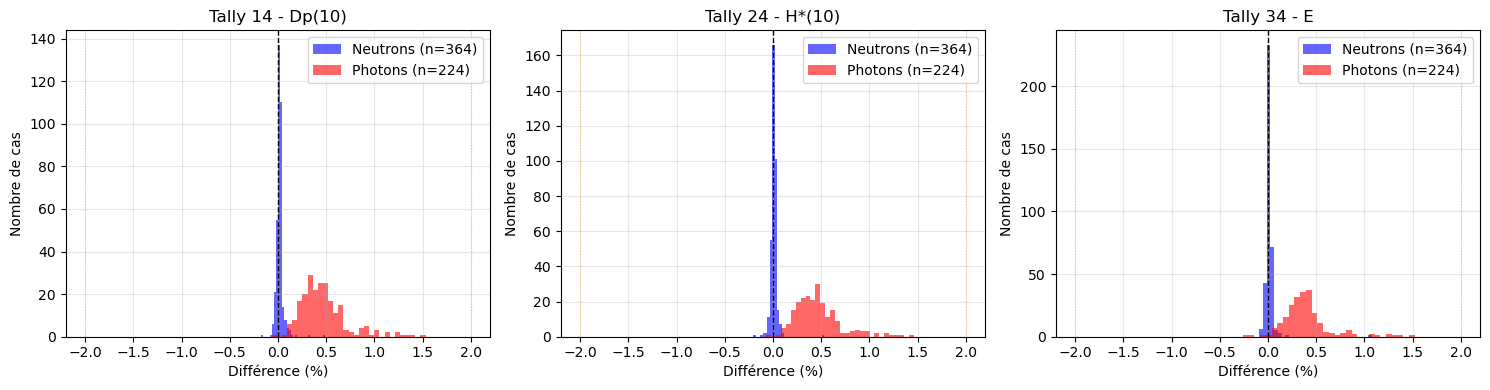

✓ Graphique sauvegardé : validation_differences.png


In [25]:
# Exemple de visualisation des différences (optionnel)
import matplotlib.pyplot as plt

# Histogrammes des différences
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (tally_num, standard) in enumerate([(14, 'Dp(10)'), (24, 'H*(10)'), (34, 'E')]):
    ax = axes[idx]
    
    # Données neutrons
    df_n = df_results_final[df_results_final['particle'] == 'N']
    diffs_n = df_n[f'diff_{tally_num}_pct'].dropna()
    
    # Données photons
    df_p = df_results_final[df_results_final['particle'] == 'P']
    diffs_p = df_p[f'diff_{tally_num}_pct'].dropna()
    
    if len(diffs_n) > 0:
        ax.hist(diffs_n, bins=30, alpha=0.6, label=f'Neutrons (n={len(diffs_n)})', color='blue')
    
    if len(diffs_p) > 0:
        ax.hist(diffs_p, bins=30, alpha=0.6, label=f'Photons (n={len(diffs_p)})', color='red')
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.axvline(x=-2, color='orange', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.axvline(x=2, color='orange', linestyle=':', linewidth=0.8, alpha=0.5)
    
    ax.set_xlabel('Différence (%)')
    ax.set_ylabel('Nombre de cas')
    ax.set_title(f'Tally {tally_num} - {standard}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/nucleon/herth-joh/scratch/SLIDERULE/MCNP/postproc/validation_differences.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé : validation_differences.png")